# 03 - EDA de Encuestas de Compradores

**Pregunta de negocio:** ¿Quiénes son nuestros compradores?

## Objetivos
- Distribuciones demográficas detalladas
- Satisfacción por segmento (tipo, ingreso, edad)
- Identificar perfiles de compradores más comunes
- Cross-tabulations con heatmaps

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
surveys = pd.read_csv(os.path.join(project_root, "data/raw/surveys/buyer_surveys.csv"), parse_dates=['purchase_date'])

# Crear grupos
surveys['age_group'] = pd.cut(surveys['age'], bins=[18, 25, 35, 45, 55, 70],
                               labels=['18-25', '26-35', '36-45', '46-55', '56-70'])
print(f"Encuestas: {len(surveys)}")

Encuestas: 500


## 1. Pirámide demográfica: Edad por género

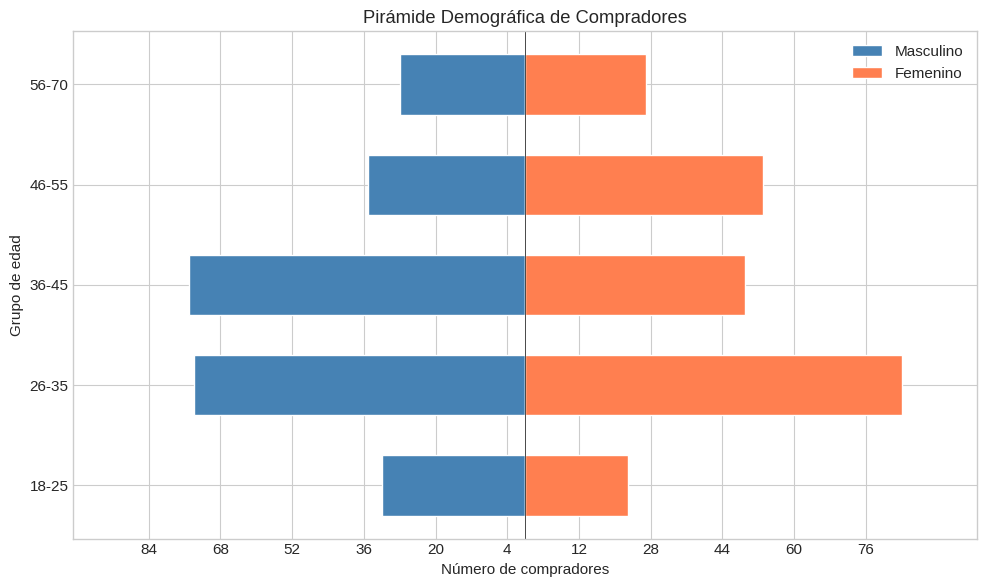

In [2]:
# Pirámide de edad por género
age_gender = surveys.groupby(['age_group', 'gender']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(age_gender))
if 'masculino' in age_gender.columns and 'femenino' in age_gender.columns:
    ax.barh(y, -age_gender['masculino'], height=0.6, color='steelblue', label='Masculino', edgecolor='white')
    ax.barh(y, age_gender['femenino'], height=0.6, color='coral', label='Femenino', edgecolor='white')
    
    max_val = max(age_gender['masculino'].max(), age_gender['femenino'].max())
    ax.set_xlim(-max_val * 1.2, max_val * 1.2)
    ax.set_xticks(np.arange(-max_val, max_val + 1, max(1, max_val // 5)))
    ax.set_xticklabels([str(abs(x)) for x in ax.get_xticks()])

ax.set_yticks(y)
ax.set_yticklabels(age_gender.index)
ax.set_xlabel('Número de compradores')
ax.set_ylabel('Grupo de edad')
ax.set_title('Pirámide Demográfica de Compradores')
ax.legend()
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 2. Satisfacción por segmentos

/tmp/ipykernel_15442/1242463408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=surveys, x='vehicle_type_purchased', y='satisfaction_score',
/tmp/ipykernel_15442/1242463408.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=surveys, x='income_bracket', y='satisfaction_score',
/tmp/ipykernel_15442/1242463408.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=surveys, x='age_group', y='satisfaction_score',


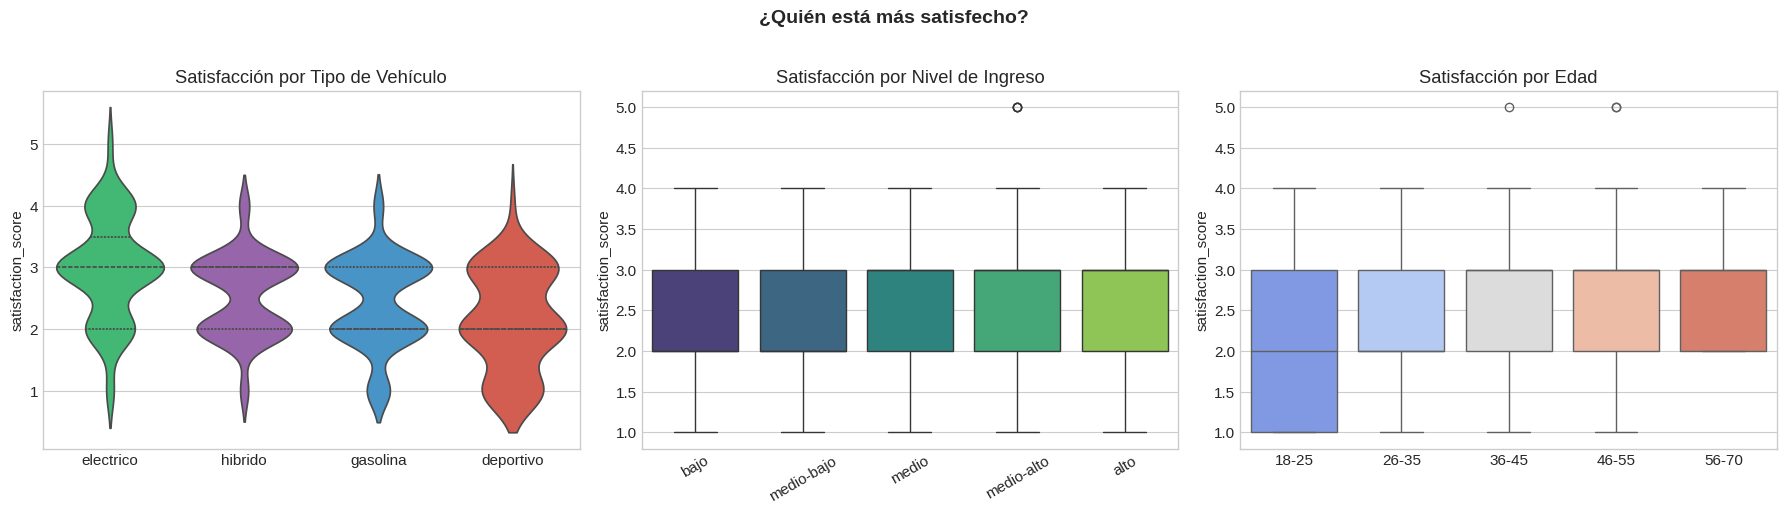

In [3]:
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Satisfacción por tipo de vehículo (violin)
sns.violinplot(data=surveys, x='vehicle_type_purchased', y='satisfaction_score',
               palette=vtype_colors, ax=axes[0], inner='quartile',
               order=['electrico', 'hibrido', 'gasolina', 'deportivo'])
axes[0].set_title('Satisfacción por Tipo de Vehículo')
axes[0].set_xlabel('')

# Satisfacción por ingreso
income_order = ['bajo', 'medio-bajo', 'medio', 'medio-alto', 'alto']
sns.boxplot(data=surveys, x='income_bracket', y='satisfaction_score',
            ax=axes[1], order=income_order, palette='viridis')
axes[1].set_title('Satisfacción por Nivel de Ingreso')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# Satisfacción por grupo de edad
sns.boxplot(data=surveys, x='age_group', y='satisfaction_score',
            ax=axes[2], palette='coolwarm')
axes[2].set_title('Satisfacción por Edad')
axes[2].set_xlabel('')

plt.suptitle('¿Quién está más satisfecho?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Crosstab heatmaps: perfiles más comunes

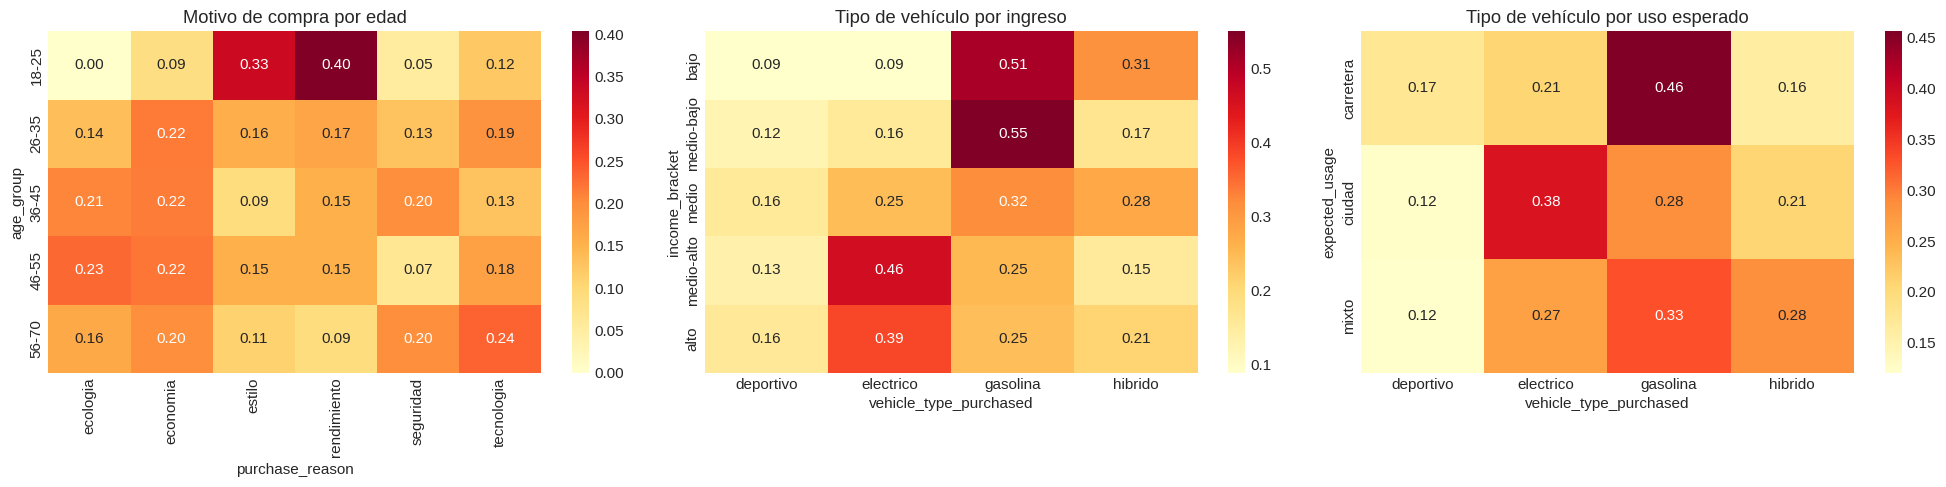

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Edad × Motivo de compra
ct1 = pd.crosstab(surveys['age_group'], surveys['purchase_reason'], normalize='index')
sns.heatmap(ct1, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Motivo de compra por edad')

# Ingreso × Tipo de vehículo
ct2 = pd.crosstab(surveys['income_bracket'], surveys['vehicle_type_purchased'], normalize='index')
ct2 = ct2.reindex(income_order)
sns.heatmap(ct2, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Tipo de vehículo por ingreso')

# Uso esperado × Tipo
ct3 = pd.crosstab(surveys['expected_usage'], surveys['vehicle_type_purchased'], normalize='index')
sns.heatmap(ct3, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('Tipo de vehículo por uso esperado')

plt.tight_layout()
plt.show()

## 4. Motivo de compra: análisis detallado

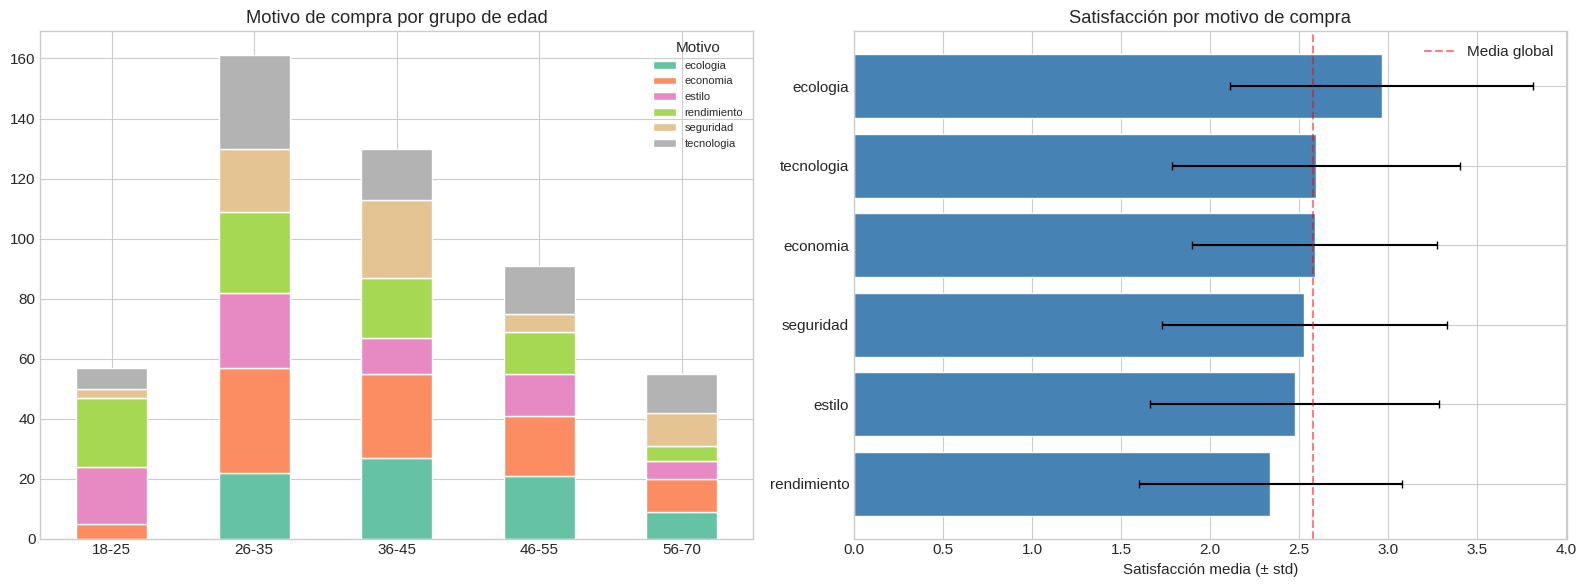

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar: motivo por grupo de edad
ct_age_reason = pd.crosstab(surveys['age_group'], surveys['purchase_reason'])
ct_age_reason.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Motivo de compra por grupo de edad')
axes[0].set_xlabel('')
axes[0].legend(title='Motivo', fontsize=8, bbox_to_anchor=(1.0, 1))
axes[0].tick_params(axis='x', rotation=0)

# Satisfacción por motivo
sat_by_reason = surveys.groupby('purchase_reason')['satisfaction_score'].agg(['mean', 'std']).sort_values('mean')
ax2 = axes[1]
ax2.barh(sat_by_reason.index, sat_by_reason['mean'], xerr=sat_by_reason['std'],
         color='steelblue', edgecolor='white', capsize=3)
ax2.set_xlabel('Satisfacción media (± std)')
ax2.set_title('Satisfacción por motivo de compra')
ax2.axvline(surveys['satisfaction_score'].mean(), color='red', linestyle='--', alpha=0.5, label='Media global')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Perfiles de comprador: combinaciones más frecuentes

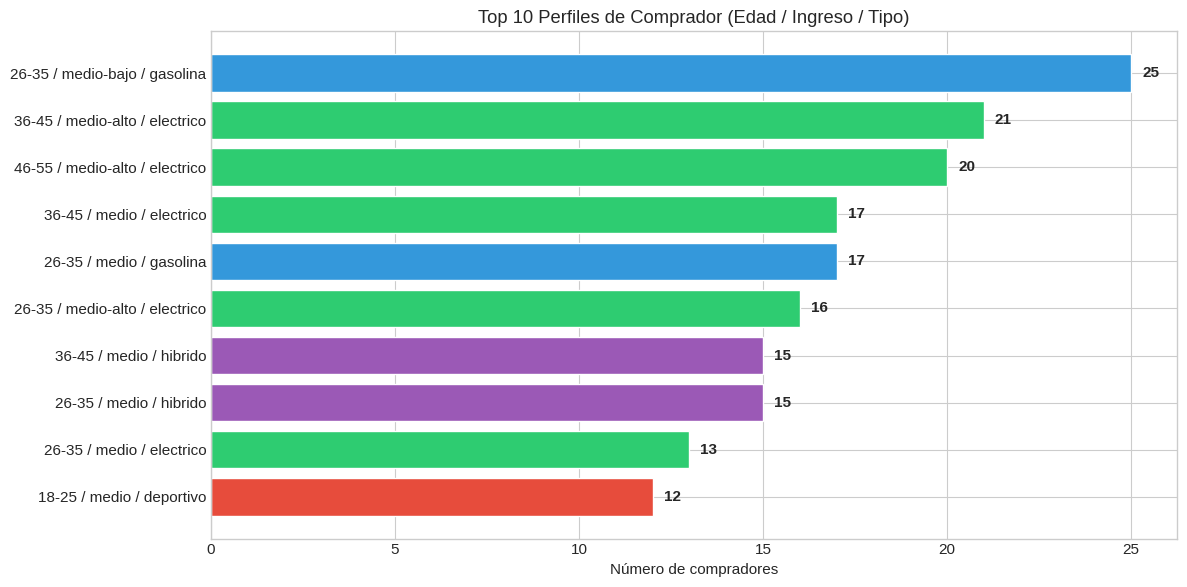

→ Estos perfiles son los 'buyer personas' más comunes en nuestros datos


In [6]:
# Top 10 combinaciones de perfil
profiles = surveys.groupby(['age_group', 'income_bracket', 'vehicle_type_purchased']).size().reset_index(name='count')
profiles = profiles.sort_values('count', ascending=False).head(10)
profiles['label'] = profiles['age_group'].astype(str) + ' / ' + profiles['income_bracket'] + ' / ' + profiles['vehicle_type_purchased']

fig, ax = plt.subplots(figsize=(12, 6))
colors = [vtype_colors.get(t, 'gray') for t in profiles['vehicle_type_purchased']]
ax.barh(profiles['label'], profiles['count'], color=colors, edgecolor='white')
ax.set_xlabel('Número de compradores')
ax.set_title('Top 10 Perfiles de Comprador (Edad / Ingreso / Tipo)')
ax.invert_yaxis()

for i, (_, row) in enumerate(profiles.iterrows()):
    ax.text(row['count'] + 0.3, i, str(row['count']), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("→ Estos perfiles son los 'buyer personas' más comunes en nuestros datos")

## 6. Recomendación: factores clave

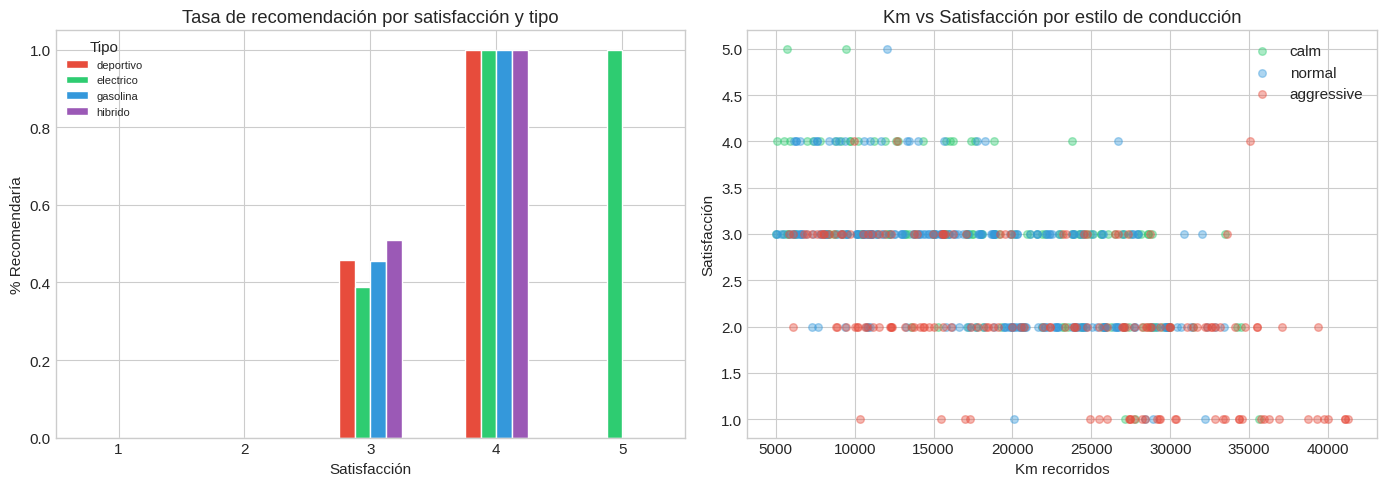

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de recomendación por satisfacción y tipo
rec_by_sat_type = surveys.groupby(['satisfaction_score', 'vehicle_type_purchased'])['would_recommend'].mean().unstack()
rec_by_sat_type.plot(kind='bar', ax=axes[0], color=[vtype_colors.get(c, 'gray') for c in rec_by_sat_type.columns],
                     edgecolor='white')
axes[0].set_title('Tasa de recomendación por satisfacción y tipo')
axes[0].set_xlabel('Satisfacción')
axes[0].set_ylabel('% Recomendaría')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Tipo', fontsize=8)

# Scatter: km vs satisfacción coloreado por driving_style
style_colors = {'calm': '#2ecc71', 'normal': '#3498db', 'aggressive': '#e74c3c'}
for style, color in style_colors.items():
    subset = surveys[surveys['driving_style'] == style]
    axes[1].scatter(subset['km_driven'], subset['satisfaction_score'],
                    alpha=0.4, s=30, color=color, label=style)
axes[1].set_xlabel('Km recorridos')
axes[1].set_ylabel('Satisfacción')
axes[1].set_title('Km vs Satisfacción por estilo de conducción')
axes[1].legend()

plt.tight_layout()
plt.show()

## Resumen

### Respuesta:
> **¿Quiénes son nuestros compradores?**
>
> El perfil dominante es adulto 26-35 con ingreso medio que compra gasolina o híbrido.
> Los jóvenes buscan rendimiento (deportivos), los mayores seguridad (híbridos).
> La satisfacción está más ligada a los km recorridos y al estilo de conducción
> que al tipo de vehículo en sí. Los compradores por ecología (eléctricos, alto ingreso)
> tienen la satisfacción más alta.

### Siguiente:
→ `04_bivariate_analysis.ipynb`: Análisis bivariado